In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 14 — Rotations, rigid transforms, and the camera model

Read `lessons/14_lesson.md` and `workbooks/14_workbook.md` first. Predict each result before executing. All outputs here are reference examples, not a grade.

**Evidence boundary:** real static stereo observations are bundled; analytical controls are labeled synthetic. No VGGT checkpoint is run by this notebook.

Source keys: G02, G03, G04, G05, G06, G07

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json, time
import numpy as np
import matplotlib.pyplot as plt
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/shape_lab").is_dir())
if str(ROOT / "src") not in sys.path: sys.path.insert(0, str(ROOT / "src"))
from shape_lab.stereo import reference_sample, point_cloud, depth_from_disparity
from shape_lab.geometry import *
from shape_lab.display import save_json, show_and_save, plot_diagram
left, right, reference_disparity, calibration = reference_sample()
OUT = ROOT / "reports" / "stage_14"
OUT.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(20260920)
print("Real data:", left.shape, right.shape, reference_disparity.shape)
print("Data source:", calibration["source"])

Real data: (500, 741, 3) (500, 741, 3) (500, 741)
Data source: scikit-image 0.26.0 stereo_motorcycle; Middlebury 2014


## 1. Frame transforms on a real point cloud
We apply a **synthetic, exactly known rigid transform** to real reference-derived points. This checks coordinate mathematics, not camera-pose estimation.

SO(3) residual: 1.6139122304055964e-16 determinant: 1.0
Rigid round trip max error (m): 1.3517848686956847e-15


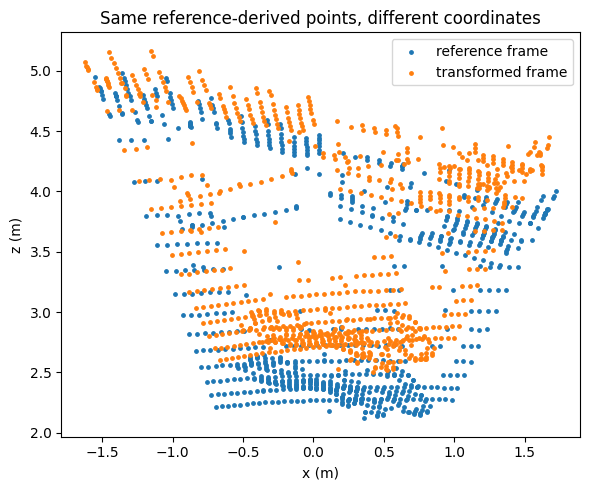

In [3]:
from scipy.spatial.transform import Rotation
cloud, rc = point_cloud(reference_disparity,calibration,stride=20)
w=np.array([0.13,-0.07,0.05]); R=exp_so3(w); t=np.array([0.2,-0.1,0.4])
T=make_transform(R,t); moved=transform_points(T,cloud)
roundtrip=transform_points(inverse_transform(T),moved)
roundtrip_max=float(np.max(np.linalg.norm(roundtrip-cloud,axis=1)))
assert roundtrip_max < 1e-12
assert np.allclose(R, Rotation.from_rotvec(w).as_matrix())
print("SO(3) residual:",np.linalg.norm(R.T@R-np.eye(3)),"determinant:",np.linalg.det(R))
print("Rigid round trip max error (m):",roundtrip_max)
plt.figure(figsize=(6,5)); plt.scatter(cloud[:,0],cloud[:,2],s=6,label="reference frame"); plt.scatter(moved[:,0],moved[:,2],s=6,label="transformed frame")
plt.xlabel("x (m)"); plt.ylabel("z (m)"); plt.title("Same reference-derived points, different coordinates"); plt.legend()
show_and_save(OUT / "frame_transform.png")

## 2. Projection and unprojection
Transform world points to camera coordinates first; `project` accepts camera-frame points. Its returned depth is the positive camera-axis Z coordinate, not the Euclidean range. Unprojection needs both the pixel and that Z value.

In [4]:
K=np.array(calibration["K_left"])
uv,z=project(cloud,K)
recovered=unproject(uv,z,K)
assert np.allclose(uv,rc[:,::-1])
assert np.allclose(recovered,cloud)
uv_scaled,z_scaled=project(3.0*cloud,K)
assert np.allclose(uv_scaled,uv)
assert np.allclose(z_scaled,3*z)
center=-R.T@t
assert np.allclose(transform_points(T,center[None,:]),0)
print("Source pixel reprojection max error:",np.max(np.abs(uv-rc[:,::-1])))
print("Camera center in input frame:",center,"not generally equal to translation:",t)
print("Identical pixels after scaling 3D distances by three:",np.allclose(uv_scaled,uv))

Source pixel reprojection max error: 1.1368683772161603e-13
Camera center in input frame: [-0.22391991  0.0588086  -0.3954762 ] not generally equal to translation: [ 0.2 -0.1  0.4]
Identical pixels after scaling 3D distances by three: True


## 3. Coordinates change when images are resized or cropped
For the explicitly defined pixel mapping `u_new = 0.5*u_old - 10`, `v_new = 0.5*v_old - 6`, use `K_new = A @ K`. This checks the algebra of that mapping, not a particular image library's half-pixel convention.

In [5]:
A=np.array([[.5,0,-10],[0,.5,-6],[0,0,1.]])
uv_new,_=project(cloud,A@K)
expected=(np.c_[uv,np.ones(len(uv))]@A.T)[:,:2]
assert np.allclose(uv_new,expected)
save_json(OUT / "results.json", {"evidence":"known transforms applied to real reference-derived cloud", "points":len(cloud),"roundtrip_max_m":roundtrip_max,"rotation_scipy_agreement":True,"projection_pixel_error_max":float(np.max(np.abs(uv-rc[:,::-1]))),"uniform_scale_projection_invariant":True,"K_update_check":True,"warning":"No pose inference, calibration fitting or VGGT inference performed here."})

## Explain before continuing
Explain the subscript order in `T_camera_world`. Give an example where composing two rotations in reverse order changes the answer. Explain why unchanged pixels under a scale change are evidence of an ambiguity, not evidence that depth is arbitrary after a metric baseline is measured.